<a href="https://colab.research.google.com/github/Virajkandikatla/GenAI_llm_Engineering_SCFP125030/blob/main/RNN_vs_LSTM_Activities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip -q install tiktoken

In [4]:
import pandas as pd
import torch
import torch.nn as nn
import tiktoken

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
torch.manual_seed(1)

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [5]:
df = pd.read_csv(
    "IMDB Dataset.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 reviews:")
display(df.head())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

First 5 reviews:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

texts = df["review"].tolist()
labels = df["sentiment"].tolist()

print("Total reviews:", len(texts))
print("Total labels:", len(labels))

print("\nLabel distribution:")
print(df["sentiment"].value_counts())

Total reviews: 50000
Total labels: 50000

Label distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [7]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.20,
    random_state=1,
    stratify=labels
)

print("Training samples:", len(train_texts))
print("Testing samples:", len(test_texts))

Training samples: 40000
Testing samples: 10000


In [8]:
enc = tiktoken.get_encoding("cl100k_base")

print("Tokenizer: cl100k_base")
print("Vocabulary size:", enc.n_vocab)

Tokenizer: cl100k_base
Vocabulary size: 100277


In [9]:
sample_tokens = enc.encode(train_texts[0])

print("Sample review:")
print(train_texts[0][:500])

print("\nFirst 20 token IDs:")
print(sample_tokens[:20])

print("\nNumber of tokens in this review:", len(sample_tokens))

Sample review:
This review contains spoilers. I didn't have any expectations about this movie. I pulled it off the video store rack with the movie, "White Noise".<br /><br />First, the credits for this stupid movie run about 5 minutes into it. The pacing from start to finish is slooooow. The main heroines don't like to wear a bra and the director appears to enjoy the jiggle effect as Anna Paquin descends the stairs. If you like movies for boobies, this one has a low level buzz factor.<br /><br />Second, it's n

First 20 token IDs:
[2028, 3477, 5727, 66427, 13, 358, 3287, 956, 617, 904, 17078, 922, 420, 5818, 13, 358, 13541, 433, 1022, 279]

Number of tokens in this review: 1220


In [10]:
MAX_LENGTH = 200

# tiktoken doesn't provide a padding token,
# so we create one outside its vocabulary.
PAD_ID = enc.n_vocab

print("Maximum sequence length:", MAX_LENGTH)
print("Padding token ID:", PAD_ID)

Maximum sequence length: 200
Padding token ID: 100277


In [11]:
def encode_and_pad(text):

    # Convert text into token IDs
    tokens = enc.encode(text)

    # Truncate if longer than MAX_LENGTH
    tokens = tokens[:MAX_LENGTH]

    # Pad if shorter than MAX_LENGTH
    if len(tokens) < MAX_LENGTH:
        tokens = tokens + [PAD_ID] * (MAX_LENGTH - len(tokens))

    return tokens

In [12]:
encoded_sample = encode_and_pad(train_texts[0])

print("Encoded sequence length:", len(encoded_sample))
print("First 30 token IDs:")
print(encoded_sample[:30])

Encoded sequence length: 200
First 30 token IDs:
[2028, 3477, 5727, 66427, 13, 358, 3287, 956, 617, 904, 17078, 922, 420, 5818, 13, 358, 13541, 433, 1022, 279, 2835, 3637, 30759, 449, 279, 5818, 11, 330, 14404, 51623]


In [13]:
print("Tokenizing training reviews...")

x_train = [encode_and_pad(text) for text in train_texts]

print("Training tokenization completed.")

print("\nTokenizing testing reviews...")

x_test = [encode_and_pad(text) for text in test_texts]

print("Testing tokenization completed.")

Tokenizing training reviews...
Training tokenization completed.

Tokenizing testing reviews...
Testing tokenization completed.


In [14]:
X_train = torch.tensor(
    x_train,
    dtype=torch.long
)

y_train = torch.tensor(
    train_labels,
    dtype=torch.float32
)

X_test = torch.tensor(
    x_test,
    dtype=torch.long
)

y_test = torch.tensor(
    test_labels,
    dtype=torch.float32
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: torch.Size([40000, 200])
y_train: torch.Size([40000])
X_test : torch.Size([10000, 200])
y_test : torch.Size([10000])


In [15]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Batch size: 64
Training batches: 625
Testing batches: 157


In [16]:
class MovieRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_size=128,
        padding_idx=None,
        dropout_prob=0.5
    ):
        super().__init__()

        # Convert token IDs into dense vectors
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        # Simple Recurrent Neural Network
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.dropout = nn.Dropout(dropout_prob)

        # Binary classification
        self.output = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        # Token IDs → embeddings
        x = self.embedding(x)

        # Run RNN
        output, hidden = self.rnn(x)

        # Take final hidden state
        hidden = self.dropout(hidden[-1])

        # Produce classification score
        return self.output(hidden).squeeze(1)

In [17]:
movie_rnn = MovieRNN(
    vocab_size=enc.n_vocab + 1,
    embedding_dim=128,
    hidden_size=128,
    padding_idx=PAD_ID,
    dropout_prob=0.5
).to(device)

print(movie_rnn)

MovieRNN(
  (embedding): Embedding(100278, 128, padding_idx=100277)
  (rnn): RNN(128, 128, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=1, bias=True)
)


In [18]:
loss_fn_rnn = nn.BCEWithLogitsLoss()

optimizer_rnn = torch.optim.Adam(
    movie_rnn.parameters(),
    lr=0.001
)

print("Loss function:", loss_fn_rnn)
print("Optimizer:", optimizer_rnn)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [19]:
EPOCHS = 10

In [20]:
rnn_train_losses = []
rnn_test_losses = []

rnn_train_accuracies = []
rnn_test_accuracies = []

for epoch in range(EPOCHS):

    # =========================
    # TRAINING
    # =========================

    movie_rnn.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        logits = movie_rnn(X_batch)

        # Calculate loss
        loss = loss_fn_rnn(logits, y_batch)

        # Clear previous gradients
        optimizer_rnn.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_rnn.step()

        train_loss += loss.item()

        # Calculate accuracy
        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        train_correct += (
            predictions == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    avg_train_loss = train_loss / len(train_loader)

    train_accuracy = (
        train_correct / train_total
    )


    # =========================
    # TESTING
    # =========================

    movie_rnn.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = movie_rnn(X_batch)

            loss = loss_fn_rnn(
                logits,
                y_batch
            )

            test_loss += loss.item()

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).float()

            test_correct += (
                predictions == y_batch
            ).sum().item()

            test_total += y_batch.size(0)

    avg_test_loss = (
        test_loss / len(test_loader)
    )

    test_accuracy = (
        test_correct / test_total
    )


    # Save results
    rnn_train_losses.append(
        avg_train_loss
    )

    rnn_test_losses.append(
        avg_test_loss
    )

    rnn_train_accuracies.append(
        train_accuracy
    )

    rnn_test_accuracies.append(
        test_accuracy
    )


    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

Epoch 1/10 | Train Loss: 0.6975 | Train Accuracy: 0.5042 | Test Loss: 0.6916 | Test Accuracy: 0.5243
Epoch 2/10 | Train Loss: 0.6908 | Train Accuracy: 0.5274 | Test Loss: 0.6940 | Test Accuracy: 0.5010
Epoch 3/10 | Train Loss: 0.6975 | Train Accuracy: 0.5004 | Test Loss: 0.6949 | Test Accuracy: 0.5067
Epoch 4/10 | Train Loss: 0.6962 | Train Accuracy: 0.5037 | Test Loss: 0.6940 | Test Accuracy: 0.4969
Epoch 5/10 | Train Loss: 0.6965 | Train Accuracy: 0.5003 | Test Loss: 0.6969 | Test Accuracy: 0.5034
Epoch 6/10 | Train Loss: 0.6961 | Train Accuracy: 0.5000 | Test Loss: 0.6935 | Test Accuracy: 0.4978
Epoch 7/10 | Train Loss: 0.6954 | Train Accuracy: 0.5030 | Test Loss: 0.6942 | Test Accuracy: 0.5051
Epoch 8/10 | Train Loss: 0.6952 | Train Accuracy: 0.5099 | Test Loss: 0.6949 | Test Accuracy: 0.5050
Epoch 9/10 | Train Loss: 0.6941 | Train Accuracy: 0.5130 | Test Loss: 0.6949 | Test Accuracy: 0.5046
Epoch 10/10 | Train Loss: 0.6926 | Train Accuracy: 0.5188 | Test Loss: 0.6942 | Test Accura

In [21]:
movie_rnn.eval()

correct = 0
total = 0
final_rnn_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = movie_rnn(X_batch)

        loss = loss_fn_rnn(
            logits,
            y_batch
        )

        final_rnn_loss += loss.item()

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

rnn_accuracy = correct / total

final_rnn_loss = (
    final_rnn_loss / len(test_loader)
)

print("===== RNN FINAL RESULTS =====")
print(f"Test Loss: {final_rnn_loss:.4f}")
print(f"Test Accuracy: {rnn_accuracy:.4f}")

===== RNN FINAL RESULTS =====
Test Loss: 0.6942
Test Accuracy: 0.5080


In [22]:
custom_reviews = [
    "The movie was fantastic and I really enjoyed it.",

    "This movie was boring, terrible and a complete waste of time.",

    "The story was interesting and the actors gave excellent performances."
]

In [23]:
def predict_rnn(text):

    movie_rnn.eval()

    encoded = encode_and_pad(text)

    x = torch.tensor(
        [encoded],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        logit = movie_rnn(x)

        probability = torch.sigmoid(
            logit
        ).item()

    if probability >= 0.5:

        sentiment = "Positive"
        confidence = probability

    else:

        sentiment = "Negative"
        confidence = 1 - probability

    print("Review:", text)
    print("RNN Prediction:", sentiment)
    print(
        f"Confidence: {confidence:.4f}"
    )
    print()

In [24]:
for review in custom_reviews:
    predict_rnn(review)

Review: The movie was fantastic and I really enjoyed it.
RNN Prediction: Positive
Confidence: 0.5284

Review: This movie was boring, terrible and a complete waste of time.
RNN Prediction: Negative
Confidence: 0.5218

Review: The story was interesting and the actors gave excellent performances.
RNN Prediction: Positive
Confidence: 0.5284



In [25]:
class MovieLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_size=128,
        padding_idx=None,
        dropout_prob=0.5
    ):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(dropout_prob)

        # Output layer for binary classification
        self.output = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        # Convert token IDs into embeddings
        x = self.embedding(x)

        # Pass embeddings through LSTM
        output, (hidden, cell) = self.lstm(x)

        # Take the final hidden state
        hidden = self.dropout(hidden[-1])

        # Classification output
        return self.output(hidden).squeeze(1)

In [26]:
movie_lstm = MovieLSTM(
    vocab_size=enc.n_vocab + 1,
    embedding_dim=128,
    hidden_size=128,
    padding_idx=PAD_ID,
    dropout_prob=0.5
).to(device)

print(movie_lstm)

MovieLSTM(
  (embedding): Embedding(100278, 128, padding_idx=100277)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=1, bias=True)
)


In [27]:
loss_fn_lstm = nn.BCEWithLogitsLoss()

optimizer_lstm = torch.optim.Adam(
    movie_lstm.parameters(),
    lr=0.001
)

print("Loss:", loss_fn_lstm)
print("Optimizer:", optimizer_lstm.__class__.__name__)

Loss: BCEWithLogitsLoss()
Optimizer: Adam


In [28]:
EPOCHS = 10

lstm_train_losses = []
lstm_test_losses = []

lstm_train_accuracies = []
lstm_test_accuracies = []

for epoch in range(EPOCHS):

    # =========================
    # TRAINING PHASE
    # =========================

    movie_lstm.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        logits = movie_lstm(X_batch)

        # Calculate loss
        loss = loss_fn_lstm(
            logits,
            y_batch
        )

        # Clear gradients
        optimizer_lstm.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_lstm.step()

        train_loss += loss.item()

        # Calculate predictions
        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        train_correct += (
            predictions == y_batch
        ).sum().item()

        train_total += y_batch.size(0)

    avg_train_loss = (
        train_loss / len(train_loader)
    )

    train_accuracy = (
        train_correct / train_total
    )


    # =========================
    # TESTING PHASE
    # =========================

    movie_lstm.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            logits = movie_lstm(X_batch)

            # Test loss
            loss = loss_fn_lstm(
                logits,
                y_batch
            )

            test_loss += loss.item()

            # Predictions
            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).float()

            test_correct += (
                predictions == y_batch
            ).sum().item()

            test_total += y_batch.size(0)

    avg_test_loss = (
        test_loss / len(test_loader)
    )

    test_accuracy = (
        test_correct / test_total
    )


    # Store results
    lstm_train_losses.append(
        avg_train_loss
    )

    lstm_test_losses.append(
        avg_test_loss
    )

    lstm_train_accuracies.append(
        train_accuracy
    )

    lstm_test_accuracies.append(
        test_accuracy
    )


    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss = {avg_train_loss:.4f} | "
        f"Train Accuracy = {train_accuracy:.4f} | "
        f"Test Loss = {avg_test_loss:.4f} | "
        f"Test Accuracy = {test_accuracy:.4f}"
    )

Epoch 1/10 | Train Loss = 0.6918 | Train Accuracy = 0.5210 | Test Loss = 0.6954 | Test Accuracy = 0.5112
Epoch 2/10 | Train Loss = 0.6834 | Train Accuracy = 0.5474 | Test Loss = 0.6846 | Test Accuracy = 0.5467
Epoch 3/10 | Train Loss = 0.6456 | Train Accuracy = 0.6253 | Test Loss = 0.6789 | Test Accuracy = 0.5582
Epoch 4/10 | Train Loss = 0.5961 | Train Accuracy = 0.6836 | Test Loss = 0.5654 | Test Accuracy = 0.7185
Epoch 5/10 | Train Loss = 0.4852 | Train Accuracy = 0.7883 | Test Loss = 0.4968 | Test Accuracy = 0.7798
Epoch 6/10 | Train Loss = 0.3722 | Train Accuracy = 0.8486 | Test Loss = 0.4322 | Test Accuracy = 0.8061
Epoch 7/10 | Train Loss = 0.2951 | Train Accuracy = 0.8867 | Test Loss = 0.4437 | Test Accuracy = 0.8229
Epoch 8/10 | Train Loss = 0.2294 | Train Accuracy = 0.9160 | Test Loss = 0.4361 | Test Accuracy = 0.8206
Epoch 9/10 | Train Loss = 0.1893 | Train Accuracy = 0.9329 | Test Loss = 0.4648 | Test Accuracy = 0.8217
Epoch 10/10 | Train Loss = 0.1491 | Train Accuracy = 0.

In [29]:
movie_lstm.eval()

correct = 0
total = 0
final_lstm_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = movie_lstm(X_batch)

        loss = loss_fn_lstm(
            logits,
            y_batch
        )

        final_lstm_loss += loss.item()

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

lstm_accuracy = correct / total

final_lstm_loss = (
    final_lstm_loss / len(test_loader)
)

print("===== LSTM FINAL RESULTS =====")
print(f"Test Loss: {final_lstm_loss:.4f}")
print(f"Test Accuracy: {lstm_accuracy:.4f}")

===== LSTM FINAL RESULTS =====
Test Loss: 0.4964
Test Accuracy: 0.8337


In [30]:
def predict_lstm(text):

    movie_lstm.eval()

    encoded = encode_and_pad(text)

    x = torch.tensor(
        [encoded],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        logit = movie_lstm(x)

        probability = torch.sigmoid(
            logit
        ).item()

    if probability >= 0.5:

        sentiment = "Positive"
        confidence = probability

    else:

        sentiment = "Negative"
        confidence = 1 - probability

    return sentiment, confidence

In [31]:
for review in custom_reviews:

    sentiment, confidence = predict_lstm(
        review
    )

    print("Review:", review)
    print("LSTM Prediction:", sentiment)
    print(f"Confidence: {confidence:.4f}")
    print()

Review: The movie was fantastic and I really enjoyed it.
LSTM Prediction: Positive
Confidence: 0.9815

Review: This movie was boring, terrible and a complete waste of time.
LSTM Prediction: Negative
Confidence: 0.9973

Review: The story was interesting and the actors gave excellent performances.
LSTM Prediction: Positive
Confidence: 0.9448



In [32]:
print("=" * 50)
print("RNN vs LSTM COMPARISON")
print("=" * 50)

print(f"RNN  Test Accuracy : {rnn_accuracy:.4f}")
print(f"LSTM Test Accuracy : {lstm_accuracy:.4f}")

print()

print(
    f"RNN  Final Train Loss : "
    f"{rnn_train_losses[-1]:.4f}"
)

print(
    f"LSTM Final Train Loss : "
    f"{lstm_train_losses[-1]:.4f}"
)

print()

print(
    f"RNN  Best Test Accuracy : "
    f"{max(rnn_test_accuracies):.4f}"
)

print(
    f"LSTM Best Test Accuracy : "
    f"{max(lstm_test_accuracies):.4f}"
)

print()

if lstm_accuracy > rnn_accuracy:

    print("LSTM achieved higher test accuracy.")

elif rnn_accuracy > lstm_accuracy:

    print("RNN achieved higher test accuracy.")

else:

    print("Both models achieved the same test accuracy.")

RNN vs LSTM COMPARISON
RNN  Test Accuracy : 0.5080
LSTM Test Accuracy : 0.8337

RNN  Final Train Loss : 0.6926
LSTM Final Train Loss : 0.1491

RNN  Best Test Accuracy : 0.5243
LSTM Best Test Accuracy : 0.8337

LSTM achieved higher test accuracy.


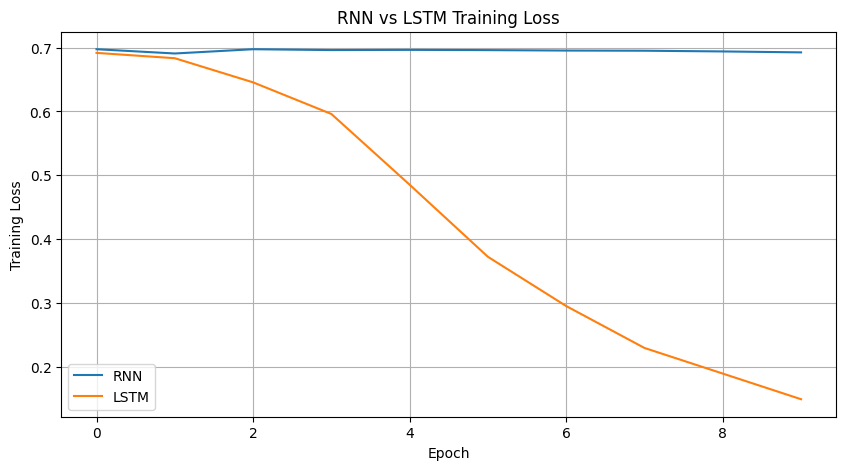

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    rnn_train_losses,
    label="RNN"
)

plt.plot(
    lstm_train_losses,
    label="LSTM"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RNN vs LSTM Training Loss")

plt.legend()
plt.grid(True)

plt.show()

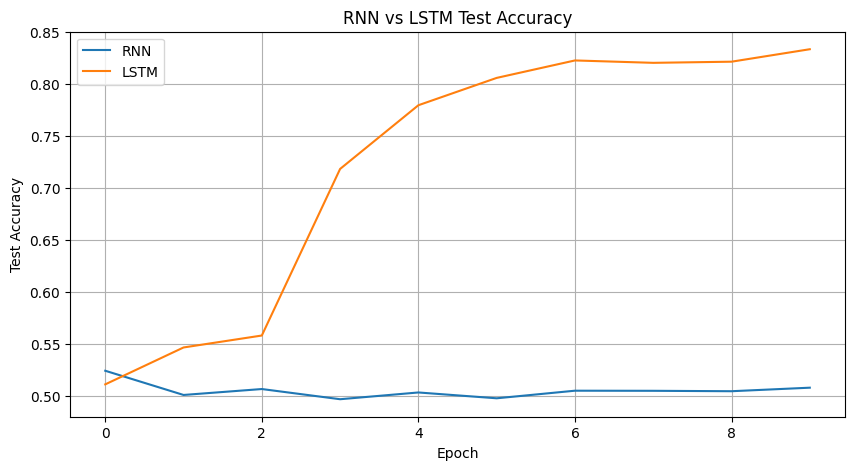

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_test_accuracies,
    label="RNN"
)

plt.plot(
    lstm_test_accuracies,
    label="LSTM"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM Test Accuracy")

plt.legend()
plt.grid(True)

plt.show()